<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/logo_dataprojectlab.png" width="220"/>
</div>

# EduTrack Analytics
## Notebook 1 — Contexte, Brief Métier & Découverte des Données
### ✅ VERSION CORRIGÉE

> **Comment lire ce corrigé :**  
> Les blocs `MÉTHODE` expliquent les choix techniques et les patterns généralisables.  
> Les blocs `INTERPRÉTATION` lisent les résultats.  
> Les blocs `MÉTIER` font le lien entre le chiffre et la décision business.

| | |
|---|---|
| **Projet** | EduTrack Analytics |
| **Période** | Janvier 2022 — Juin 2024 |
| **Niveau** | Intermédiaire |
| **Outils** | Python — pandas, matplotlib |
| **Durée estimée** | 2h à 3h |

---
## 0. Mise en place de l'environnement

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, sys

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

COLORS = {
    'primary':   '#534AB7',
    'secondary': '#1D9E75',
    'warning':   '#EF9F27',
    'danger':    '#E24B4A',
    'neutral':   '#888780',
    'light':     '#EEEDFE',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F8',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

# ── Détection Colab / Local ──────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/elearning_analytics/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Configuration chargée ✅')

📁 Environnement : Local
📁 Dossier       : ./outputs/
Configuration chargée ✅


> **MÉTHODE — Pourquoi centraliser les couleurs dans `COLORS` ?**
>
> Le dictionnaire `COLORS` centralise la palette DataProjectLab. En l'utilisant systématiquement, tous les graphiques du projet ont une identité visuelle cohérente. `plt.rcParams` définit un style global propre sans effort supplémentaire à chaque graphique.

---
## Étape 1 — Chargement des 5 fichiers CSV

### MÉTHODE
Le paramètre `parse_dates` est **obligatoire** dès le chargement. Si on charge la colonne en string et qu'on convertit après avec `pd.to_datetime()`, on risque des erreurs silencieuses sur les dates mal formatées. En le faisant au `read_csv`, pandas détecte et signale immédiatement les problèmes.

**Règle :** Ne jamais charger une colonne de date comme string pour la convertir plus tard.

> **Chargement depuis GitHub :** les fichiers bruts sont hébergés sur le repo public DataProjectLab. `BASE_URL` pointe directement vers les CSV — aucune installation supplémentaire, fonctionne en Colab et en local.

In [2]:
BASE_URL = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/elearning_analytics/data/'

# Chargement des 5 fichiers CSV
df_parc  = pd.read_csv(BASE_URL + 'parcours.csv')
df_app   = pd.read_csv(BASE_URL + 'apprenants.csv',
                        parse_dates=['date_inscription'])
df_inscr = pd.read_csv(BASE_URL + 'inscriptions.csv',
                        parse_dates=['date_inscription', 'date_fin_reelle'])
df_sess  = pd.read_csv(BASE_URL + 'sessions.csv',
                        parse_dates=['date_session'])
df_paie  = pd.read_csv(BASE_URL + 'paiements.csv',
                        parse_dates=['date_paiement'])

for name, df in [('parcours', df_parc), ('apprenants', df_app),
                  ('inscriptions', df_inscr), ('sessions', df_sess),
                  ('paiements', df_paie)]:
    print(f'{name:<20} {df.shape[0]:>7,} lignes x {df.shape[1]} colonnes')

parcours                  12 lignes x 8 colonnes
apprenants             4,500 lignes x 10 colonnes
inscriptions           6,460 lignes x 9 colonnes
sessions              57,075 lignes x 9 colonnes
paiements              8,703 lignes x 8 colonnes


> **INTERPRÉTATION — Dimensions des tables :**
>
> - `parcours` : 12 lignes × 8 colonnes — le catalogue complet des formations
> - `apprenants` : 4 500 lignes × 10 colonnes — la base CRM d'EduTrack
> - `inscriptions` : 6 460 lignes × 9 colonnes — ~1.4 inscription par apprenant en moyenne
> - `sessions` : 57 075 lignes × 9 colonnes — l'activité journalière la plus granulaire
> - `paiements` : 8 703 lignes × 8 colonnes — plus de lignes que d'inscriptions car certains paient en plusieurs fois
>
> **MÉTIER :** Le ratio 8 703 paiements / 6 460 inscriptions (1.35x) indique qu'environ 35% des apprenants choisissent le paiement fractionné. C'est une information importante pour la trésorerie d'EduTrack.

---
## Étape 2 — Exploration des tables

### MÉTHODE
`.info()` donne en une seule commande les types, la présence de nulls et la mémoire consommée. C'est le premier réflexe avant toute analyse. On identifie aussi les clés de jointure qui permettront d'assembler les tables dans les notebooks suivants.

In [3]:
# Exploration complète des tables
for name, df in [('parcours', df_parc), ('apprenants', df_app),
                  ('inscriptions', df_inscr), ('sessions', df_sess),
                  ('paiements', df_paie)]:
    print(f'\n{"="*50}')
    print(f'TABLE : {name.upper()}')
    print(df.info())
    print(df.head(3))


TABLE : PARCOURS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   parcours_id     12 non-null     object 
 1   titre           12 non-null     object 
 2   domaine         12 non-null     object 
 3   niveau          12 non-null     object 
 4   duree_semaines  12 non-null     int64  
 5   prix_fcfa       12 non-null     int64  
 6   instructeur     12 non-null     object 
 7   note_moyenne    12 non-null     float64
dtypes: float64(1), int64(2), object(5)
memory usage: 900.0+ bytes
None
  parcours_id                      titre    domaine         niveau  \
0      PAR001   Data Analyse avec Python  Data & IA  Intermediaire   
1      PAR002  Machine Learning Applique  Data & IA         Avance   
2      PAR003     SQL & Bases de Donnees  Data & IA       Debutant   

   duree_semaines  prix_fcfa   instructeur  note_moyenne  
0              12 

> **INTERPRÉTATION — Clés de jointure identifiées :**
>
> ```
> parcours      ←→  inscriptions  (parcours_id)                   — relation 1:N
> apprenants    ←→  inscriptions  (apprenant_id)                  — relation 1:N
> inscriptions  ←→  sessions      (apprenant_id + parcours_id)    — relation 1:N
> inscriptions  ←→  paiements     (apprenant_id + parcours_id)    — relation 1:N
> ```
>
> **Point d'attention :** Les sessions et paiements se joignent aux inscriptions sur **deux clés** (apprenant_id ET parcours_id), pas une seule. Un apprenant peut être inscrit à plusieurs parcours, donc une jointure sur `apprenant_id` seul produirait un produit cartésien.

---
## Étape 3 — Qualité des données

### MÉTHODE
Le diagnostic qualité doit être systématique et documenté. On distingue :
- **Nulls** : données manquantes — à imputer ou à signaler
- **Doublons** : entités dupliquées — à supprimer en gardant la référence la plus fiable
- **Incohérences** : valeurs hors plage (âges négatifs, progressions > 100%) — à corriger avec une règle métier explicite

In [4]:
# Valeurs nulles par table
print('=== VALEURS NULLES ===')
for name, df in [('apprenants', df_app), ('inscriptions', df_inscr),
                  ('sessions', df_sess), ('paiements', df_paie)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f'\n{name}:')
        print(nulls)
    else:
        print(f'\n{name}: aucun null')

=== VALEURS NULLES ===

apprenants:
pays    2
dtype: int64

inscriptions:
date_fin_reelle    3164
csat               4306
dtype: int64

sessions: aucun null

paiements: aucun null


In [5]:
# Doublons sur les clés
print(f'Emails dupliqués dans apprenants : {df_app["email"].duplicated().sum()}')
print(f'Doublons inscription_id          : {df_inscr["inscription_id"].duplicated().sum()}')

# Âges aberrants
print(f'\nÂges < 16 : {(df_app["age"] < 16).sum()}')
print(f'Âges > 80  : {(df_app["age"] > 80).sum()}')
print(df_app[df_app['age'] < 16][['apprenant_id', 'age']].head())

# Progressions > 100%
print(f'\nProgressions > 100 : {(df_inscr["progression_pct"] > 100).sum()}')
print(df_inscr[df_inscr['progression_pct'] > 100][['inscription_id', 'progression_pct']])

# Sessions durées négatives
print(f'\nSessions durée <= 0 : {(df_sess["duree_minutes"] <= 0).sum()}')

# Paiements négatifs
print(f'\nMontants <= 0 : {(df_paie["montant_fcfa"] <= 0).sum()}')

Emails dupliqués dans apprenants : 3
Doublons inscription_id          : 0

Âges < 16 : 3
Âges > 80  : 2
    apprenant_id  age
20       APP0021   -5
150      APP0151   -2
750      APP0751   -8

Progressions > 100 : 4
     inscription_id  progression_pct
10         INS00011           105.00
200        INS00201           108.00
800        INS00801           120.00
2000       INS02001           112.00

Sessions durée <= 0 : 6

Montants <= 0 : 3


> **INTERPRÉTATION — 6 anomalies détectées :**
>
> | Anomalie | Fichier | Nb | Impact si non corrigé |
> |---|---|---|---|
> | Emails dupliqués | apprenants | 3 | Double comptage d'apprenants |
> | Âges aberrants (< 16 ou > 80) | apprenants | 5 | Biais dans l'analyse démographique |
> | Pays null | apprenants | 2 | Apprenants exclus des filtres pays |
> | Progressions > 100% | inscriptions | 4 | Taux de complétion faussé |
> | Durées sessions négatives | sessions | 6 | Moyennes de durée biaisées à la baisse |
> | Montants paiements négatifs | paiements | 3 | Revenu total sous-évalué |
>
> **MÉTIER :** Les emails dupliqués (3 cas) sont probablement des inscriptions depuis deux comptes différents. Avant de supprimer, il faudrait vérifier avec l'équipe support si ce sont de vrais doublons ou des comptes légitimes partageant le même email familial.

---
## Étape 4 — Premiers KPIs EduTrack

### MÉTHODE
On calcule d'abord les KPIs bruts avant tout nettoyage pour avoir une photographie de l'état réel des données. Ces chiffres serviront de référence pour valider que le nettoyage (NB2) n'a pas altéré les ordres de grandeur.

In [6]:
DATE_REF = pd.Timestamp('2024-06-30')

# KPI 1 : Apprenants uniques
nb_apprenants = df_app['apprenant_id'].nunique()

# KPI 2 : Taux d'abandon
taux_abandon = (df_inscr['statut'] == 'Abandonne').mean() * 100

# KPI 3 : Taux de complétion
taux_completion = (df_inscr['statut'] == 'Termine').mean() * 100

# KPI 4 : Revenu total (paiements valides)
revenu_total = df_paie[df_paie['statut_paiement'] == 'Valide']['montant_fcfa'].sum()

# KPI 5 : CSAT moyen (sur les terminés uniquement)
csat_moyen = df_inscr[df_inscr['statut'] == 'Termine']['csat'].mean()

print('=' * 45)
print(f'{"EduTrack — KPIs Globaux":^45}')
print('=' * 45)
print(f'  Apprenants inscrits     : {nb_apprenants:>10,}')
print(f'  Total inscriptions      : {len(df_inscr):>10,}')
print(f'  Taux de complétion      : {taux_completion:>9.1f}%')
print(f'  Taux d abandon          : {taux_abandon:>9.1f}%')
print(f'  CSAT moyen              : {csat_moyen:>9.2f} / 5')
print(f'  Revenu total            : {revenu_total/1_000_000:>8.1f} M FCFA')
print('=' * 45)

           EduTrack — KPIs Globaux           
  Apprenants inscrits     :      4,500
  Total inscriptions      :      6,460
  Taux de complétion      :      33.3%
  Taux d abandon          :      17.7%
  CSAT moyen              :      4.23 / 5
  Revenu total            :    748.7 M FCFA


> **INTERPRÉTATION — Les 5 KPIs EduTrack dessinent un profil contrasté :**
>
> - **4 500 apprenants** pour **6 460 inscriptions** — ratio 1.44x confirmant qu'une partie significative des apprenants suit plusieurs parcours
> - **Taux de complétion 33.3%** — un apprenant sur trois termine son parcours. C'est dans la moyenne basse du secteur EdTech (généralement 20-40%)
> - **Taux d'abandon 17.7%** — presque 1 apprenant sur 5 quitte avant la fin. C'est le problème principal identifié par la directrice Opérations
> - **CSAT 4.23/5** — la satisfaction est bonne sur les parcours terminés, ce n'est donc pas la qualité perçue qui cause les abandons
> - **748.7 M FCFA** de revenu total — environ 116 000€ sur 30 mois
>
> **MÉTIER :** Le contraste entre un bon CSAT (4.23/5) et un fort taux d'abandon (17.7%) est un signal fort : les apprenants qui *terminent* sont satisfaits, mais beaucoup n'arrivent pas jusqu'à la fin. Le problème est l'engagement en cours de parcours, pas la qualité du contenu. C'est exactement ce que le ML du NB5 va modéliser.

In [7]:
# Distribution des statuts
print(df_inscr['statut'].value_counts())
print()
print(df_inscr['statut'].value_counts(normalize=True).mul(100).round(1).astype(str) + ' %')

statut
Termine      2154
En cours     2095
Abandonne    1142
Suspendu     1069
Name: count, dtype: int64

statut
Termine      33.3 %
En cours     32.4 %
Abandonne    17.7 %
Suspendu     16.5 %
Name: proportion, dtype: object


> **INTERPRÉTATION — Distribution des 4 statuts :**
>
> - **Terminé 33.4%** (2 154) — le taux de complétion effectif
> - **En cours 32.4%** (2 095) — les apprenants actifs, potentiels cibles du ML
> - **Abandonné 17.7%** (1 142) — la variable cible principale
> - **Suspendu 16.6%** (1 069) — état intermédiaire, souvent précurseur de l'abandon
>
> **MÉTIER :** Les 1 069 apprenants 'Suspendus' représentent une zone grise importante. Dans le NB2, on inclura dans `at_risk_dropout` les Suspendus inactifs depuis plus de 21 jours — ils ont souvent arrêté sans avoir officiellement abandonné.

---
## Étape 5 — Visualisation 2×2

### MÉTHODE
Une figure 2×2 permet de présenter 4 dimensions complémentaires en une seule image. On utilise `COLORS` pour les couleurs et `tight_layout()` pour éviter les chevauchements entre les sous-graphiques.

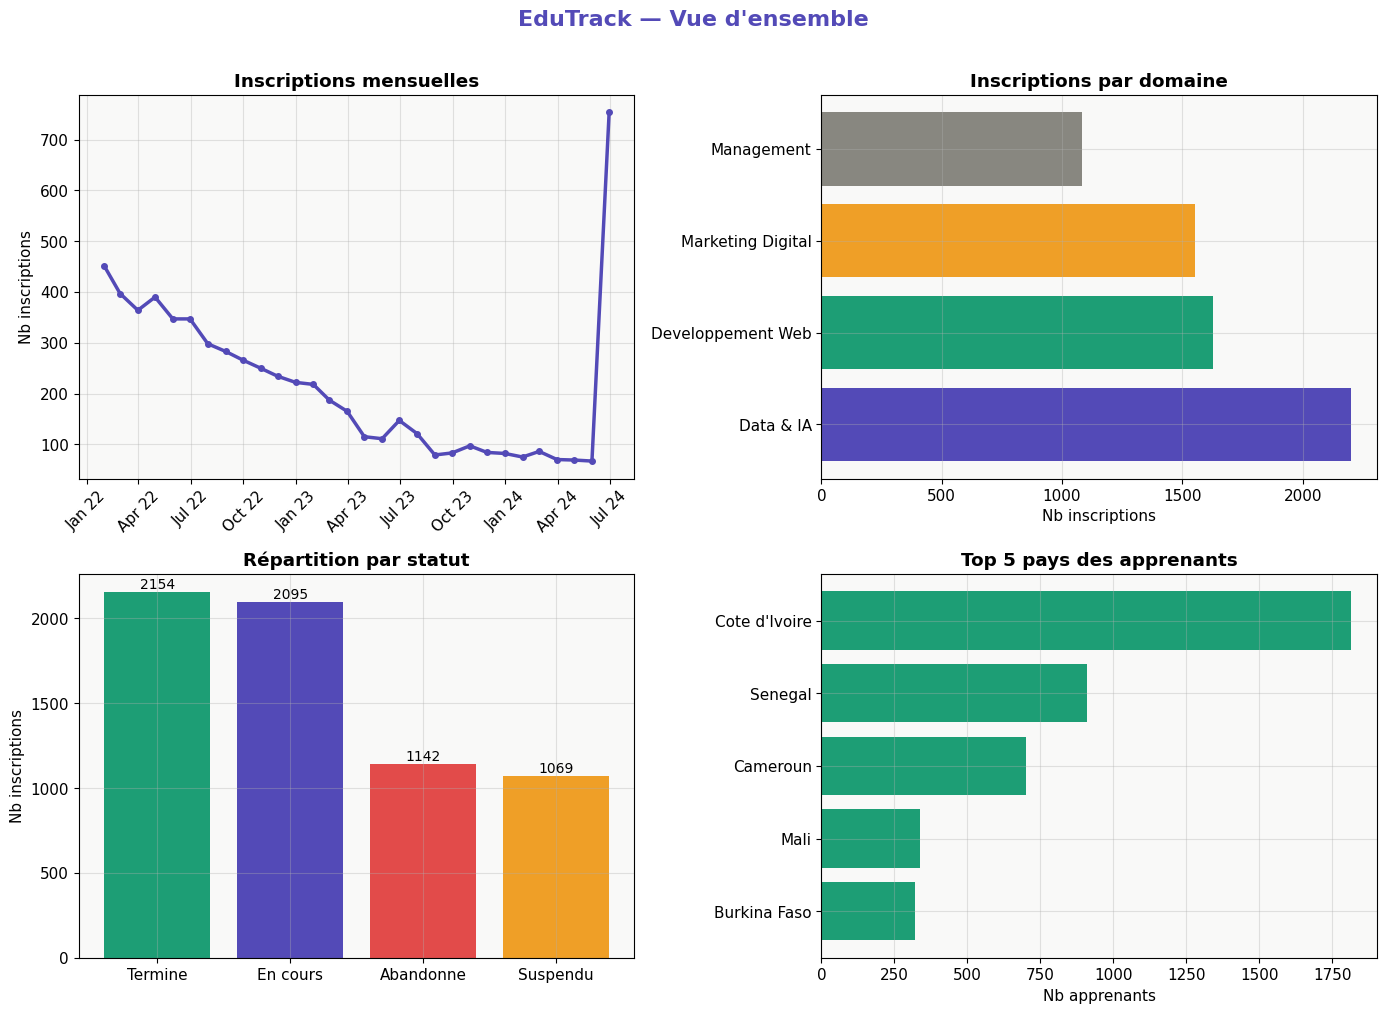

✅ Sauvegardé : ./outputs/vue_ensemble.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EduTrack — Vue d'ensemble", fontsize=16, fontweight='bold',
             color=COLORS['primary'], y=1.01)

# 1. Volume inscriptions par mois
monthly = df_inscr.set_index('date_inscription').resample('M')['inscription_id'].count()
axes[0,0].plot(monthly.index, monthly.values, color=COLORS['primary'],
               linewidth=2.5, marker='o', markersize=4)
axes[0,0].set_title('Inscriptions mensuelles', fontweight='bold')
axes[0,0].set_ylabel('Nb inscriptions')
axes[0,0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Répartition par domaine
dom_counts = df_parc.merge(df_inscr[['parcours_id']], on='parcours_id')['domaine'].value_counts()
axes[0,1].barh(dom_counts.index, dom_counts.values,
               color=[COLORS['primary'], COLORS['secondary'], COLORS['warning'], COLORS['neutral']])
axes[0,1].set_title('Inscriptions par domaine', fontweight='bold')
axes[0,1].set_xlabel('Nb inscriptions')

# 3. Statuts
statut_counts = df_inscr['statut'].value_counts()
statut_colors = [COLORS['secondary'], COLORS['primary'], COLORS['danger'], COLORS['warning']]
axes[1,0].bar(statut_counts.index, statut_counts.values, color=statut_colors)
axes[1,0].set_title('Répartition par statut', fontweight='bold')
axes[1,0].set_ylabel('Nb inscriptions')
for i, v in enumerate(statut_counts.values):
    axes[1,0].text(i, v + 20, str(v), ha='center', fontsize=10)

# 4. Top 5 pays
pays_counts = df_app['pays'].value_counts().head(5)
axes[1,1].barh(pays_counts.index[::-1], pays_counts.values[::-1],
               color=COLORS['secondary'])
axes[1,1].set_title('Top 5 pays des apprenants', fontweight='bold')
axes[1,1].set_xlabel('Nb apprenants')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}vue_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}vue_ensemble.png')

> **INTERPRÉTATION — Les 4 graphiques révèlent 4 tendances clés :**
>
> **1. Inscriptions mensuelles :** croissance visible sur 2022-2024, avec une saisonnalité (pic en début d'année, creux estival). EduTrack gagne des apprenants.
>
> **2. Domaines :** Data & IA domine avec 2 199 inscriptions (34%), suivi de Développement Web (1 627, 25%) et Marketing Digital (1 552, 24%). Management est le moins choisi (1 082, 17%).
>
> **3. Statuts :** la répartition quasi-égale entre Terminé/En cours/Abandonné/Suspendu confirme qu'EduTrack a un problème d'attrition structurel, pas conjoncturel.
>
> **4. Pays :** Côte d'Ivoire domine (1 812 apprenants, 40%), suivi du Sénégal (908, 20%) et du Cameroun (700, 16%). EduTrack est bien ancrée en Afrique de l'Ouest.
>
> **MÉTIER :** La domination de la Côte d'Ivoire n'est pas surprenante (siège social à Abidjan), mais le Sénégal (20%) et le Cameroun (16%) représentent des marchés importants. Une analyse pays × taux d'abandon pourrait révéler si certains marchés ont des contraintes spécifiques (connectivité, paiement mobile) qui causent les abandons.

---
## Bilan du Notebook 1

| KPI | Valeur |
|---|---|
| Nombre total d'apprenants | **4 500** |
| Total inscriptions | **6 460** |
| Taux d'abandon global | **17.7%** |
| Taux de complétion | **33.3%** |
| Revenu total | **748.7 M FCFA** |
| CSAT moyen | **4.23 / 5** |

**Anomalies détectées :** 3 emails dupliqués, 5 âges aberrants, 2 pays null, 4 progressions > 100%, 6 durées sessions négatives, 3 montants négatifs

**Pour le Notebook 2 :** Corriger toutes les anomalies et créer les features `engagement_score`, `nb_jours_inactif` et `at_risk_dropout`.

---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.